dataset_link : https://www.kaggle.com/code/prashant111/mnist-deep-neural-network-with-keras/input?select=test.csv

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential # to build neural network layer by layer
from tensorflow.keras.layers import Dense ,Conv2D , Flatten
#dense to make final layer prediction
#conv2D is to extract features
#flatten reshapes them
from tensorflow.keras.layers import MaxPooling2D # reduces size
from tensorflow.keras.layers import Dropout # to avoid overfitting
from tensorflow.keras.utils import to_categorical # to convert no. into one-hot encoding
from tensorflow import keras


In [75]:
df=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')


In [76]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
df['label']

,label
0,1
1,0
2,1
3,4
4,0
...,...
41995,0
41996,1
41997,7
41998,6


In [78]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
df.shape

(42000, 785)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [81]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [82]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [83]:
X=df.drop("label",axis=1).values
y=df["label"].values


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [85]:
X_test=X_test.astype('float32')/255.0
X_train=X_train.astype('float32')/255.0

In [86]:
X_train=X_train.reshape(-1,28,28)
X_test=X_test.reshape(-1,28,28)


In [87]:
y_train = to_categorical(y_train,num_classes = 10)
y_test = to_categorical(y_test,num_classes = 10)

In [88]:
cnn= keras.Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

In [89]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [90]:
history = cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.8922 - loss: 0.3578 - val_accuracy: 0.9679 - val_loss: 0.1100
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9565 - loss: 0.1461 - val_accuracy: 0.9767 - val_loss: 0.0755
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9682 - loss: 0.1081 - val_accuracy: 0.9799 - val_loss: 0.0653
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.9735 - loss: 0.0884 - val_accuracy: 0.9824 - val_loss: 0.0572
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9773 - loss: 0.0745 - val_accuracy: 0.9838 - val_loss: 0.0534


In [91]:
acc_cnn=cnn.evaluate(X_test,y_test, verbose=1)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9838 - loss: 0.0534


In [92]:
acc_cnn

[0.05343431606888771, 0.9838095307350159]

In [93]:
import numpy as np

# Make predictions on the test set
predictions = cnn.predict(X_test)

# Convert predictions from probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

print("First 5 predicted labels:")
print(predicted_labels[:5])

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
First 5 predicted labels:
[8 1 9 9 8]


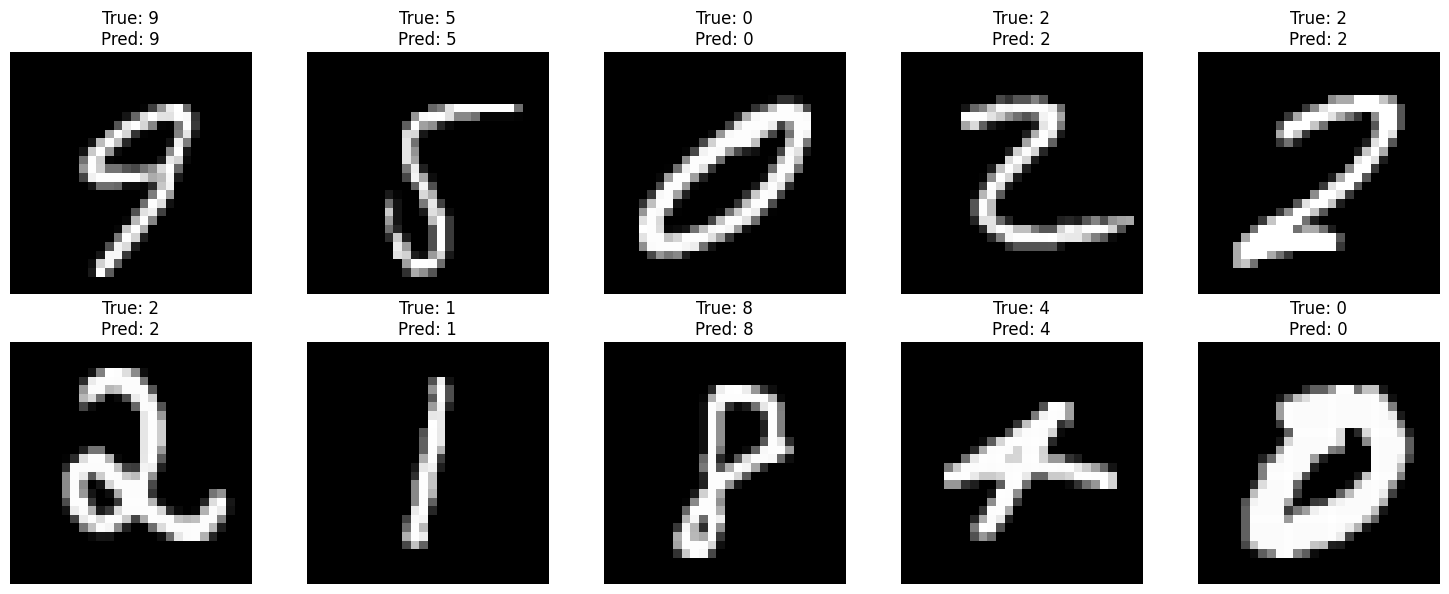

In [98]:
import matplotlib.pyplot as plt

# Get the true labels from y_test (convert one-hot back to integer)
true_labels = np.argmax(y_test, axis=1)

# Select a few random images from the test set
num_images_to_display = 10
random_indices = np.random.choice(len(X_test), num_images_to_display, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1) # Arrange in 2 rows, 5 columns
    # Reshape the image from (28, 28) to display correctly
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_labels[idx]}\nPred: {predicted_labels[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()